# Appendix A: Microdata Analysis (Individual Demographics)
**Research Questions Addressed: RQ1 and RQ3**
This notebook contains the data ingestion, exploratory data analysis (EDA), and machine learning pipeline for the individual-level Global Findex survey data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Data
file_path = '../data/raw/findex_microdata_2025_labelled_update112425.csv' 

print("Loading data...")
df = pd.read_csv(file_path)
print(f"Data loaded successfully! Shape: {df.shape}")
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

Loading data...
Data loaded successfully! Shape: (144090, 199)


In [2]:
# Displaying first 5 rows of the dataset
df.head()

,year,economy,economycode,regionwb,pop_adult,wpid_random,wgt,female,age,educ,...,fin48e,fin48f,fin49a,fin49b,fin49c,fin49d,fin49e,fin49f,fin50,fin51
0,2024,Nicaragua,NIC,Latin America & Caribbean (excluding high income),4830854,111111345,0.927315,1,53,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024,Costa Rica,CRI,Latin America & Caribbean (excluding high income),4118576,111111579,1.383884,2,48,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024,Mali,MLI,Sub-Saharan Africa (excluding high income),12725942,111112511,1.323486,1,40,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024,Kuwait,KWT,High income,3950546,111113432,1.475693,1,25,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
4,2024,Turkiye,TUR,Europe & Central Asia (excluding high income),66691005,111115194,0.651801,2,72,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0


In [3]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Total duplicates: {duplicate_count}")

Total duplicates: 0


In [4]:
# Check missing values in your target column before dropping them
target_missing = df['dig_account'].isnull().sum()
target_pct = (target_missing / len(df)) * 100
print(f"Missing targets: {target_missing} ({target_pct:.2f}%)")

Missing targets: 41136 (28.55%)


In [5]:
# Check missing values in Age
age_missing = df['age'].isnull().sum()
age_pct = (age_missing / len(df)) * 100
print(f"Missing age values: {age_missing} ({age_pct:.2f}%)")

Missing age values: 0 (0.00%)


In [6]:
# Check missing values for your categorical features
cat_cols = ['educ', 'inc_q', 'internet_use']
cat_missing_total = df[cat_cols].isnull().sum().sum()
cat_pct = (cat_missing_total / (len(df) * len(cat_cols))) * 100
print(f"Total missing categoricals: {cat_missing_total} ({cat_pct:.2f}%)")

# Or if you want to see them individually to sum them up yourself:
print(df[cat_cols].isnull().sum())

Total missing categoricals: 1608 (0.37%)
educ             588
inc_q           1020
internet_use       0
dtype: int64


### Phase 1: Data Cleaning and Exploratory Data Analysis (RQ1)
The following code isolates the target variable (`dig_account`), handles missing categorical and continuous values via mode/median imputation, and generates the correlation heatmap to identify the primary drivers of digital adoption.

In [7]:
# 2. Data Cleaning
print("\n--- Starting Data Cleaning ---")
# Drop rows where the target variable is missing
df = df.dropna(subset=['dig_account'])

# Fill missing values for demographic features
# (Median for continuous 'age', Mode for categorical variables)
df['age'] = df['age'].fillna(df['age'].median())
df['inc_q'] = df['inc_q'].fillna(df['inc_q'].mode()[0])
df['educ'] = df['educ'].fillna(df['educ'].mode()[0])
df['internet_use'] = df['internet_use'].fillna(df['internet_use'].mode()[0])

print("Data cleaning complete. Checking for missing values in key columns:")
print(df[['age', 'female', 'inc_q', 'educ', 'internet_use', 'dig_account']].isnull().sum())


--- Starting Data Cleaning ---
Data cleaning complete. Checking for missing values in key columns:
age             0
female          0
inc_q           0
educ            0
internet_use    0
dig_account     0
dtype: int64


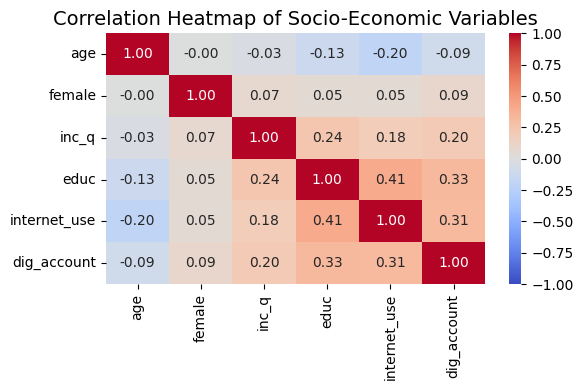

In [8]:
# 3. EDA - Correlation Heatmap
plt.figure(figsize=(6, 4))
cols_to_corr =['age', 'female', 'inc_q', 'educ', 'internet_use', 'dig_account']
corr_matrix = df[cols_to_corr].corr(method='pearson')

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Socio-Economic Variables', fontsize=14)
plt.tight_layout()
plt.show()

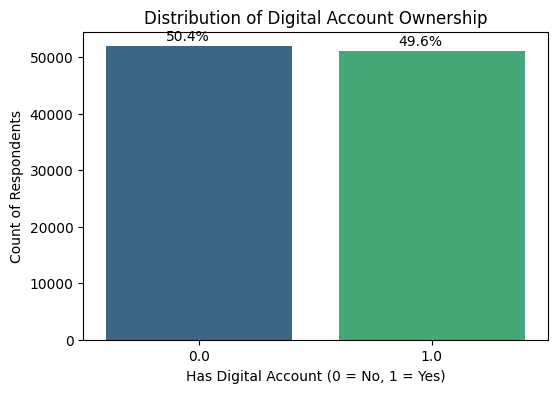

In [9]:
# Distribution of Digital Account Ownership
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='dig_account', data=df, palette='viridis')
plt.title('Distribution of Digital Account Ownership')
plt.xlabel('Has Digital Account (0 = No, 1 = Yes)')
plt.ylabel('Count of Respondents')
# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 1000
    ax.annotate(percentage, (x, y), ha='center')
plt.show()

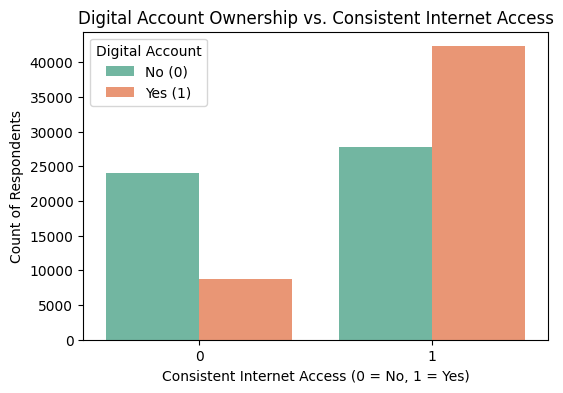

In [10]:
# Adoption by Internet Access (Grouped Bar Chart)
plt.figure(figsize=(6, 4))
sns.countplot(x='internet_use', hue='dig_account', data=df, palette='Set2')
plt.title('Digital Account Ownership vs. Consistent Internet Access')
plt.xlabel('Consistent Internet Access (0 = No, 1 = Yes)')
plt.ylabel('Count of Respondents')
plt.legend(title='Digital Account', labels=['No (0)', 'Yes (1)'])
plt.show()

In [12]:
# 4. EDA - Cross-Tabulation (Table 3)
crosstab_result = pd.crosstab(
    index=df['inc_q'],
    columns=df['dig_account'],
    normalize='index' # Shows percentages across the row
) * 100

crosstab_result.index =['Quintile 1 (Poorest)', 'Quintile 2', 'Quintile 3', 'Quintile 4', 'Quintile 5 (Richest)']
crosstab_result.columns =['No Digital Account (%)', 'Has Digital Account (%)']

print("\n--- Table 3: Cross-Tabulation of Income Quintile vs. Digital Account Ownership ---")
display(crosstab_result.round(2))


--- Table 3: Cross-Tabulation of Income Quintile vs. Digital Account Ownership ---


,No Digital Account (%),Has Digital Account (%)
Quintile 1 (Poorest),65.65,34.35
Quintile 2,58.52,41.48
Quintile 3,52.73,47.27
Quintile 4,46.53,53.47
Quintile 5 (Richest),36.51,63.49


### Phase 2: Predictive Modeling and Odds Ratios (RQ3)
The following code scales continuous features, balances regional class discrepancies using SMOTE, and fits a Multivariate Logistic Regression model. Extracting the coefficients ($e^\beta$) provides actionable odds ratios for infrastructural thresholds. Visual evidence includes the Confusion Matrix and ROC Curve.

In [13]:
#Importing necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, recall_score

In [14]:
# 1. Define Features (X) and Target (y)
X = df[['age', 'female', 'inc_q', 'educ', 'internet_use']]
y = df['dig_account']

In [15]:
# 2. Feature Engineering: Scale the continuous 'age' variable
# (This ensures 'age' doesn't artificially skew the model compared to categorical variables like 1-5)
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled['age'] = scaler.fit_transform(X[['age']])

In [16]:
# 3. Train-Test Split (80% Training data, 20% Testing data)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [17]:
# 4. Initialize and Train the Model
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, y_train); # Semicolon suppresses HTML output

In [20]:
print("--- Starting Predictive Modelling (Logistic Regression) ---\n")
# 5. Evaluate the Model
y_pred = log_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred) # How many true adopters did we successfully find?

print("--- Preliminary Model Evaluation ---")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Recall (Sensitivity): {recall * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

--- Starting Predictive Modelling (Logistic Regression) ---

--- Preliminary Model Evaluation ---
Accuracy: 67.57%
Recall (Sensitivity): 70.43%

Classification Report:
               precision    recall  f1-score   support

         0.0       0.69      0.65      0.67     10384
         1.0       0.66      0.70      0.68     10207

    accuracy                           0.68     20591
   macro avg       0.68      0.68      0.68     20591
weighted avg       0.68      0.68      0.68     20591



In [22]:
# 6. Extract Odds Ratios (Table 4)
# This explains exactly HOW MUCH a feature impacts the odds of adopting digital banking.
odds_ratios = np.exp(log_model.coef_[0])

odds_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0],
    'Odds Ratio': odds_ratios
}).sort_values(by='Odds Ratio', ascending=False)

print("\n--- Table 4: Extracted Odds Ratios ---")
display(odds_df.round(3))


--- Table 4: Extracted Odds Ratios ---


,Feature,Coefficient,Odds Ratio
4,internet_use,0.961,2.614
3,educ,0.739,2.095
1,female,0.273,1.314
2,inc_q,0.182,1.200
0,age,-0.062,0.940


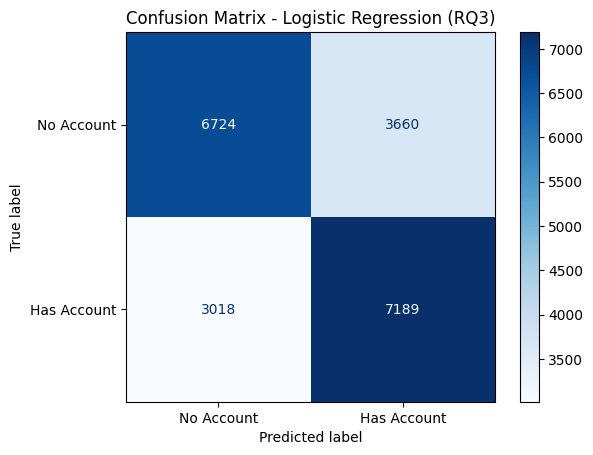

In [23]:
# 7. Visual Evidence for RQ3 (Final Report Requirement)
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# --- A. Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred) # assuming y_pred is your log_model.predict(X_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Account', 'Has Account'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Logistic Regression (RQ3)")
plt.show()

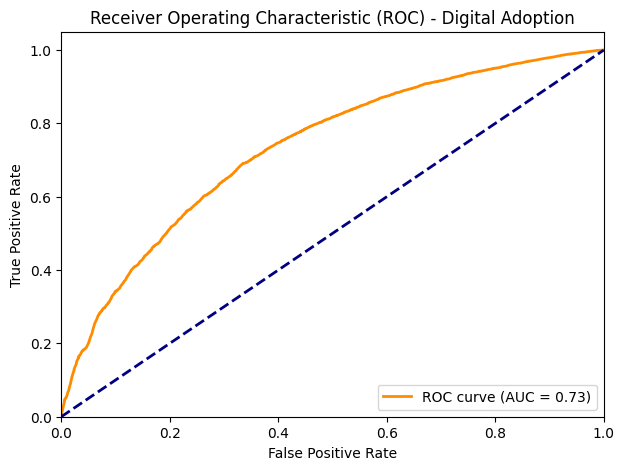

In [24]:
# --- B. ROC Curve ---
y_pred_prob = log_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Digital Adoption')
plt.legend(loc="lower right")
plt.show()

### Phase 3: Model Deployment Simulation
Simulating a backend API to demonstrate the "Example Use Case" for FinTech and NGO stakeholders. It accepts demographic parameters and outputs the exact probability of a demographic adopting digital banking.

In [25]:
# ==========================================
# 8. Deployment Simulation (For Final Report: Example Use Case)
# ==========================================
import pandas as pd
print("\n--- Model Deployment Simulation ---")

def predict_adoption_probability(age, is_female, income_quintile, education_level, has_internet):
    # Format the new user's data
    new_user = pd.DataFrame({
        'age':[age],
        'female': [is_female], # 1 for Female, 2 for Male 
        'inc_q': [income_quintile], # 1 (Poorest) to 5 (Richest)
        'educ': [education_level], # 1 (Primary) to 3 (Tertiary)
        'internet_use': [has_internet] # 0 for No, 1 for Yes
    })
    
    # Scale age using the scaler we fitted earlier
    new_user_scaled = new_user.copy()
    new_user_scaled['age'] = scaler.transform(new_user[['age']])
    
    # Predict probability
    prob = log_model.predict_proba(new_user_scaled)[0][1]
    
    print(f"User Profile: Age {age}, Internet: {'Yes' if has_internet==1 else 'No'}, Educ: Level {education_level}")
    print(f"-> Probability of adopting digital banking: {prob * 100:.2f}%\n")

# Test User A: 25 years old, has internet, tertiary education, rich
predict_adoption_probability(age=25, is_female=2, income_quintile=5, education_level=3, has_internet=1)

# Test User B: 45 years old, NO internet, primary education, poor
predict_adoption_probability(age=45, is_female=1, income_quintile=1, education_level=1, has_internet=0)


--- Model Deployment Simulation ---
User Profile: Age 25, Internet: Yes, Educ: Level 3
-> Probability of adopting digital banking: 84.41%

User Profile: Age 45, Internet: No, Educ: Level 1
-> Probability of adopting digital banking: 13.89%

